# Bias Analysis
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import ast

## 1 - Data Loading

We load the clean dataset exported by the Data Engineering pipeline (`clean_credit_applications.csv`). A few type conversions are required since CSV serialisation flattens booleans to strings and nested objects to stringified lists:
- **`decision.loan_approved`**: convert `"True"`/`"False"` strings to actual booleans
- **`applicant_info.date_of_birth`**: derive applicant **age** and define **age groups**
- **`spending_behavior`**: parse stringified list back to Python objects for category-level analysis
- Records with `gender = UNKNOWN` (3 records) are **excluded** from protected-attribute analysis to avoid distorting group rates

In [2]:
# Load the clean dataset produced by the Data Engineering pipeline
df = pd.read_csv('../data/clean_credit_applications.csv')

# decision.loan_approved is stored as 'True'/'False' strings in CSV — convert to boolean
df['decision.loan_approved'] = df['decision.loan_approved'].astype(bool)

# Derive applicant age from date_of_birth (standardised to ISO 8601 in notebook 01)
df['age'] = (pd.Timestamp('today') - pd.to_datetime(df['applicant_info.date_of_birth'])).dt.days // 365

# Bin age into groups for group-level analysis
age_bins   = [17, 29, 44, 59, 120]
age_labels = ['<30', '30-44', '45-59', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Parse spending_behavior from its stringified list format in CSV
df['spending_behavior_parsed'] = df['spending_behavior'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

# For protected-attribute analysis, exclude the 3 UNKNOWN gender records
df_gender = df[df['applicant_info.gender'].isin(['Male', 'Female'])].copy()

print(f'Total clean records loaded : {len(df)}')
print(f'Records with known gender  : {len(df_gender)}')
print(f'\nGender distribution:')
print(df['applicant_info.gender'].value_counts())
print(f'\nAge range: {df["age"].min()}–{df["age"].max()} years')
print(f'\nAge group distribution:')
print(df['age_group'].value_counts().sort_index())

Total clean records loaded : 494
Records with known gender  : 494

Gender distribution:
applicant_info.gender
Female    248
Male      246
Name: count, dtype: int64

Age range: 23–67 years

Age group distribution:
age_group
<30       82
30-44    256
45-59    113
60+       43
Name: count, dtype: int64


## 2 - Overview of Protected Attributes

### 1. Gender Distribution

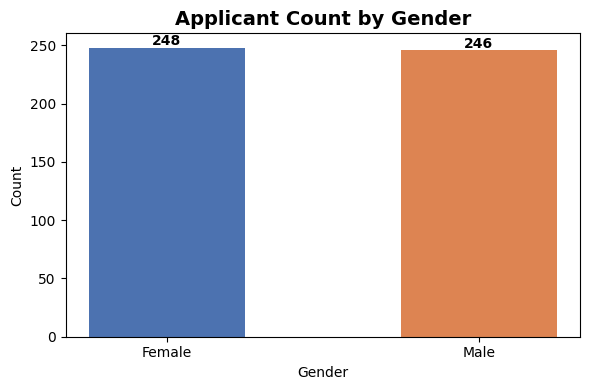

applicant_info.gender
Female    248
Male      246
Name: count, dtype: int64


In [3]:
gender_counts = df_gender['applicant_info.gender'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(gender_counts.index, gender_counts.values, color=['#4C72B0', '#DD8452'], width=0.5)
ax.set_title('Applicant Count by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
for bar, val in zip(bars, gender_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 2, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(gender_counts)

Male (246) and female (248) applicants are nearly equally split, a balanced sample that gives the statistical tests solid power to detect real differences.

### 2. Age Distribution

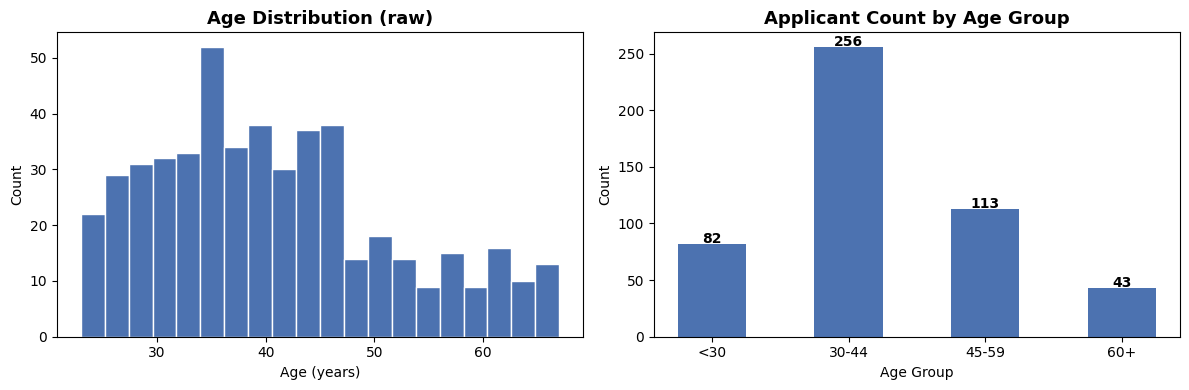

age_group
<30       82
30-44    256
45-59    113
60+       43
Name: count, dtype: int64


In [4]:
age_group_counts = df['age_group'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['age'].dropna(), bins=20, color='#4C72B0', edgecolor='white')
axes[0].set_title('Age Distribution (raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

bars = axes[1].bar(age_group_counts.index.astype(str), age_group_counts.values, color='#4C72B0', width=0.5)
axes[1].set_title('Applicant Count by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
for bar, val in zip(bars, age_group_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 1, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(age_group_counts)

The 30–44 group dominates with 256 applicants, while 60+ has only 43, meaning discrimination patterns for older applicants are harder to detect with confidence.

### 3. Overall Approval Rate

In [5]:
overall_rate = df['decision.loan_approved'].mean()
approved     = df['decision.loan_approved'].sum()
rejected     = (~df['decision.loan_approved']).sum()

print(f'Overall approval rate : {overall_rate:.1%}')
print(f'Approved              : {approved}')
print(f'Rejected              : {rejected}')

Overall approval rate : 58.3%
Approved              : 288
Rejected              : 206


## 3 - Bias Patterns

### 1. Gender Disparate Impact

As required by the project specification (§6.2), we apply the **Disparate Impact (DI) ratio** — the standard metric used by the EEOC's *four-fifths rule* to detect discrimination:

$$DI = \frac{\text{Approval rate of unprivileged group}}{\text{Approval rate of privileged group}}$$

A DI value **below 0.8** indicates potential disparate impact. We treat **Male** as the privileged group and **Female** as unprivileged. A **chi-squared test** verifies whether the difference in approval rates is statistically significant.

Approval rates by gender:
  Female: 50.8%
  Male: 65.9%

Disparate Impact Ratio (DI) : 0.772
Four-fifths rule             : FAIL — potential disparate impact detected

Chi-squared test (gender vs approval):
  chi2 = 10.8912, p = 0.0010, dof = 1
  Result: Statistically significant (p < 0.05)


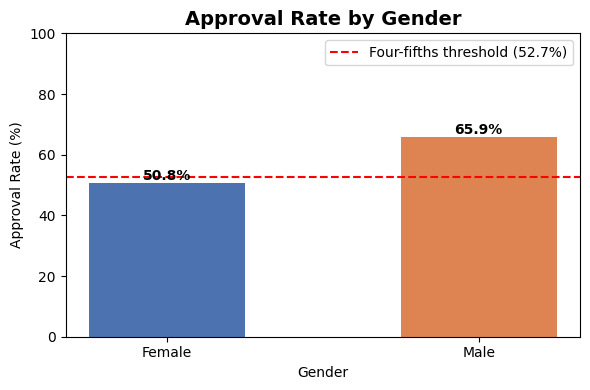

In [6]:
# --- Compute DI ---
approval_by_gender = df_gender.groupby('applicant_info.gender')['decision.loan_approved'].mean()
di = approval_by_gender['Female'] / approval_by_gender['Male']
di_verdict = 'FAIL — potential disparate impact detected' if di < 0.8 else 'PASS'

print('Approval rates by gender:')
for gender, rate in approval_by_gender.items():
    print(f'  {gender}: {rate:.1%}')
print(f'\nDisparate Impact Ratio (DI) : {di:.3f}')
print(f'Four-fifths rule             : {di_verdict}')

# --- Chi-squared test ---
contingency_gender = pd.crosstab(df_gender['applicant_info.gender'], df_gender['decision.loan_approved'])
chi2_gender, p_gender, dof_gender, _ = stats.chi2_contingency(contingency_gender)
sig_gender = 'Statistically significant (p < 0.05)' if p_gender < 0.05 else 'Not statistically significant'

print(f'\nChi-squared test (gender vs approval):')
print(f'  chi2 = {chi2_gender:.4f}, p = {p_gender:.4f}, dof = {dof_gender}')
print(f'  Result: {sig_gender}')

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(approval_by_gender.index, approval_by_gender.values * 100, color=['#4C72B0', '#DD8452'], width=0.5)
threshold = approval_by_gender['Male'] * 100 * 0.8
ax.axhline(y=threshold, color='red', linestyle='--', label=f'Four-fifths threshold ({threshold:.1f}%)')
ax.set_title('Approval Rate by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Approval Rate (%)')
ax.set_ylim(0, 100)
ax.legend()
for bar, val in zip(bars, approval_by_gender.values * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

With a DI of 0.772, women's approval rate (50.8%) falls below the four-fifths threshold relative to men (65.9%). The result is statistically significant (p = 0.001), meaning the algorithm approves men at a substantially higher rate and constitutes potential disparate impact.

### 2. Age-Based Discrimination Patterns

Age is a protected characteristic under EU anti-discrimination law. We analyse approval rates across age groups to detect whether older or younger applicants face systematically worse outcomes. A chi-squared test checks statistical significance.

Approval rates by age group:
  <30: 41.5% (82.0 applicants)
  30-44: 60.9% (256.0 applicants)
  45-59: 61.9% (113.0 applicants)
  60+: 65.1% (43.0 applicants)

Chi-squared test (age group vs approval):
  chi2 = 11.7338, p = 0.0084, dof = 3
  Result: Statistically significant (p < 0.05)


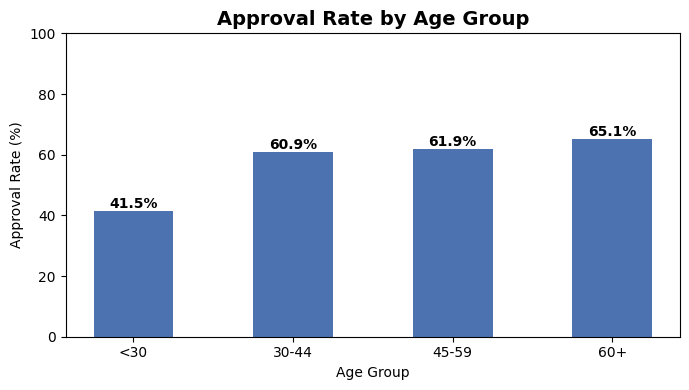

In [7]:
approval_by_age = df.groupby('age_group', observed=True)['decision.loan_approved'].agg(['mean', 'count'])
approval_by_age.columns = ['approval_rate', 'count']

print('Approval rates by age group:')
for group, row in approval_by_age.iterrows():
    print(f'  {group}: {row["approval_rate"]:.1%} ({row["count"]} applicants)')

contingency_age = pd.crosstab(df['age_group'], df['decision.loan_approved'])
chi2_age, p_age, dof_age, _ = stats.chi2_contingency(contingency_age)
sig_age = 'Statistically significant (p < 0.05)' if p_age < 0.05 else 'Not statistically significant'

print(f'\nChi-squared test (age group vs approval):')
print(f'  chi2 = {chi2_age:.4f}, p = {p_age:.4f}, dof = {dof_age}')
print(f'  Result: {sig_age}')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(approval_by_age.index.astype(str), approval_by_age['approval_rate'] * 100, color='#4C72B0', width=0.5)
ax.set_title('Approval Rate by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Approval Rate (%)')
ax.set_ylim(0, 100)
for bar, val in zip(bars, approval_by_age['approval_rate'] * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Applicants under 30 are approved at only 41.5%, compared to 60–65% for all older groups (p = 0.008). The algorithm systematically disadvantages younger applicants, most likely through their shorter financial histories.

### 3. Proxy Variable Analysis

Proxy discrimination occurs when a seemingly neutral attribute is strongly correlated with a protected characteristic **and** with the outcome — effectively substituting for the protected attribute. We investigate four candidate proxies:
1. **Financial attributes** (`annual_income`, `savings_balance`) as proxies for gender (gender pay gap)
2. **`credit_history_months`** as a proxy for age (older applicants accumulate more credit history by definition)
3. **`zip_code`** as a geographic proxy for demographic groups (redlining)
4. **Spending categories** (e.g. `Alcohol`) as lifestyle proxies for gender

#### 3a. Correlation Heatmap — Financial Features vs Outcome

We first map the overall correlation landscape between all numeric fields and `loan_approved`.

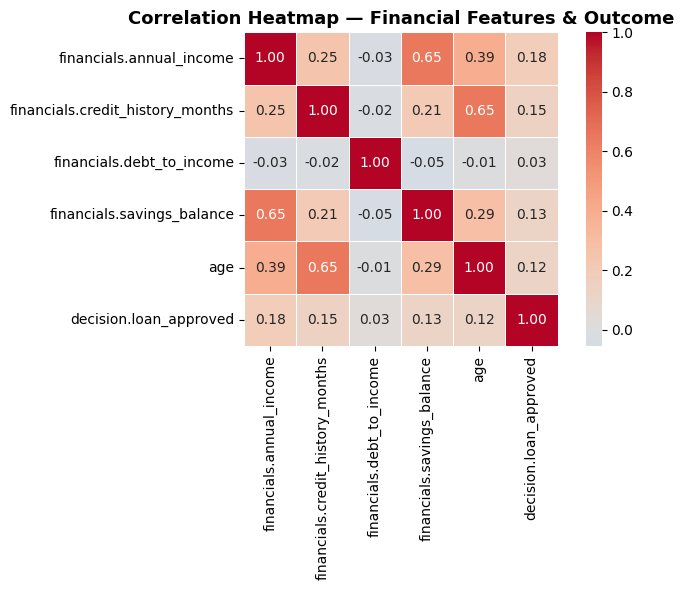

Correlations with loan_approved (sorted):
financials.annual_income            0.181157
financials.credit_history_months    0.146446
financials.savings_balance          0.125492
age                                 0.119554
financials.debt_to_income           0.025272
Name: decision.loan_approved, dtype: float64


In [8]:
numeric_cols = [
    'financials.annual_income',
    'financials.credit_history_months',
    'financials.debt_to_income',
    'financials.savings_balance',
    'age',
    'decision.loan_approved'
]

corr_df = df[numeric_cols].copy()
corr_df['decision.loan_approved'] = corr_df['decision.loan_approved'].astype(int)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Financial Features & Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlations with loan_approved (sorted):')
print(corr_matrix['decision.loan_approved'].drop('decision.loan_approved').sort_values(ascending=False))

Features most predictive of approval appear in the `loan_approved` column, where positive values are rewarded by the algorithm and negative ones penalised. Any feature that ranks high here and also links to a protected attribute is a proxy candidate worth investigating.

#### 3b. Gender Income Gap — Is `annual_income` a Proxy for Gender?

If income distributions differ significantly between male and female applicants **and** income correlates with the approval outcome, then income could act as a proxy for gender. We use an independent samples **t-test** to test this hypothesis.

Note: while a gender pay gap exists in real-world data, this is a synthetic dataset — we make no assumptions and let the test decide.

Income distribution by gender:
  Male   — mean: $81,358 | median: $81,000
  Female — mean: $83,599 | median: $82,000

Independent t-test (income: Male vs Female):
  t = -0.8833, p = 0.3775
  Result: No significant income gap detected


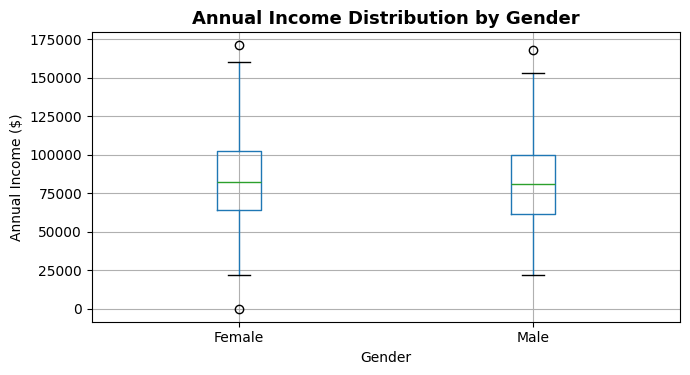

In [9]:
male_income   = df_gender[df_gender['applicant_info.gender'] == 'Male']['financials.annual_income'].dropna()
female_income = df_gender[df_gender['applicant_info.gender'] == 'Female']['financials.annual_income'].dropna()

t_stat_income, p_income = stats.ttest_ind(male_income, female_income)
sig_income = 'Significant income gap — income is a potential gender proxy' if p_income < 0.05 else 'No significant income gap detected'

print('Income distribution by gender:')
print(f'  Male   — mean: ${male_income.mean():,.0f} | median: ${male_income.median():,.0f}')
print(f'  Female — mean: ${female_income.mean():,.0f} | median: ${female_income.median():,.0f}')
print(f'\nIndependent t-test (income: Male vs Female):')
print(f'  t = {t_stat_income:.4f}, p = {p_income:.4f}')
print(f'  Result: {sig_income}')

fig, ax = plt.subplots(figsize=(7, 4))
df_gender.boxplot(column='financials.annual_income', by='applicant_info.gender', ax=ax)
ax.set_title('Annual Income Distribution by Gender', fontsize=13, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Annual Income ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()

Income distributions for men ($81,358) and women ($83,599) are virtually identical, and the t-test is not significant (p = 0.38). Income is not acting as a gender proxy in this dataset.

#### 3c. Credit History as an Age Proxy

`credit_history_months` captures how long an applicant has been building credit. By definition, older applicants have had more time to accumulate history — making this field a structural proxy for age. We measure this with a **Pearson correlation**.

Pearson correlation — age vs credit_history_months:
  r = 0.6489, p = 0.0000
  Result: Significant positive correlation — credit_history_months is a proxy for age


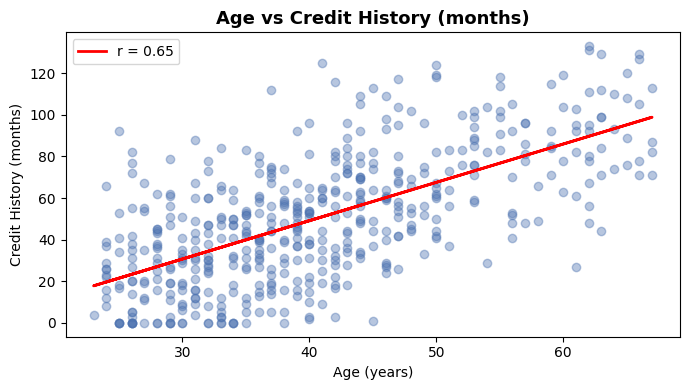

In [10]:
valid = df[['age', 'financials.credit_history_months']].dropna()
r_credit_age, p_credit_age = stats.pearsonr(valid['age'], valid['financials.credit_history_months'])
sig_credit = 'Significant positive correlation — credit_history_months is a proxy for age' if (p_credit_age < 0.05 and r_credit_age > 0) else 'No significant proxy relationship detected'

print('Pearson correlation — age vs credit_history_months:')
print(f'  r = {r_credit_age:.4f}, p = {p_credit_age:.4f}')
print(f'  Result: {sig_credit}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(valid['age'], valid['financials.credit_history_months'], alpha=0.4, color='#4C72B0')
m, b = np.polyfit(valid['age'], valid['financials.credit_history_months'], 1)
ax.plot(valid['age'], m * valid['age'] + b, color='red', linewidth=2, label=f'r = {r_credit_age:.2f}')
ax.set_title('Age vs Credit History (months)', fontsize=13, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Credit History (months)')
ax.legend()
plt.tight_layout()
plt.show()

A strong positive correlation (r = 0.65, p < 0.001) confirms that older applicants accumulate significantly more credit history. Since credit history feeds into the algorithm, young applicants are penalised structurally, not for their financial behaviour but simply for how long they have been alive.

#### 3d. ZIP Code as a Geographic Proxy

ZIP codes encode geographic location which correlates with demographic composition. Two main prefixes appear in the dataset (`100xx` → New York area, `902xx` → Los Angeles area). We check whether approval rates differ significantly between geographic clusters — a modern form of **redlining**.

Approval rates by ZIP prefix (>=10 applicants):
  100xx: 64.3% (249.0 applicants)
  300xx: 55.6% (18.0 applicants)
  902xx: 52.0% (227.0 applicants)

Chi-squared test (zip_prefix vs approval):
  chi2 = 7.4171, p = 0.0245
  Result: Statistically significant — ZIP code is a potential geographic proxy


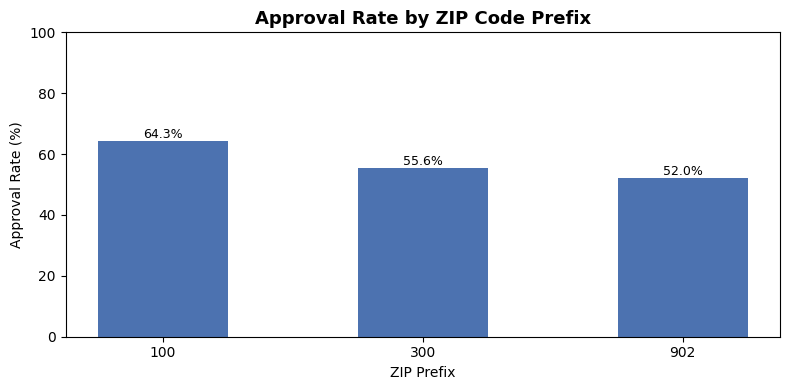

In [11]:
df_zip = df[df['applicant_info.zip_code'] != 'UNKNOWN_ZIP'].copy()
df_zip['zip_prefix'] = df_zip['applicant_info.zip_code'].astype(str).str[:3]

zip_stats = (
    df_zip.groupby('zip_prefix')['decision.loan_approved']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'approval_rate', 'count': 'count'})
)
zip_stats = zip_stats[zip_stats['count'] >= 10].sort_values('approval_rate', ascending=False)

print('Approval rates by ZIP prefix (>=10 applicants):')
for prefix, row in zip_stats.iterrows():
    print(f'  {prefix}xx: {row["approval_rate"]:.1%} ({row["count"]} applicants)')

contingency_zip = pd.crosstab(df_zip['zip_prefix'], df_zip['decision.loan_approved'])
chi2_zip, p_zip, dof_zip, _ = stats.chi2_contingency(contingency_zip)
sig_zip = 'Statistically significant — ZIP code is a potential geographic proxy' if p_zip < 0.05 else 'No significant geographic bias detected'

print(f'\nChi-squared test (zip_prefix vs approval):')
print(f'  chi2 = {chi2_zip:.4f}, p = {p_zip:.4f}')
print(f'  Result: {sig_zip}')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(zip_stats.index, zip_stats['approval_rate'] * 100, color='#4C72B0', width=0.5)
ax.set_title('Approval Rate by ZIP Code Prefix', fontsize=13, fontweight='bold')
ax.set_xlabel('ZIP Prefix')
ax.set_ylabel('Approval Rate (%)')
ax.set_ylim(0, 100)
for bar, val in zip(bars, zip_stats['approval_rate'] * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

NYC-area applicants (100xx) are approved at 64.3% versus 52.0% for LA-area applicants (902xx), a statistically significant difference (p = 0.025). Geographic location is influencing credit decisions beyond what financial profiles alone can justify.

#### 3e. Spending Behavior as an Age Proxy

Spending categories reflect lifestyle habits that vary strongly with age — younger applicants tend to spend on Entertainment, Dining, and Alcohol, while older applicants spend more on Healthcare, Insurance, and Utilities. If certain categories are penalised by the algorithm, it may be indirectly disadvantaging specific age groups.

Spending categories found: ['Adult Entertainment', 'Alcohol', 'Dining', 'Education', 'Entertainment', 'Fitness', 'Gambling', 'Groceries', 'Healthcare', 'Insurance', 'Rent', 'Shopping', 'Transportation', 'Travel', 'Utilities']

Correlation with loan_approved by spending category:
rent                  -0.093999
dining                -0.058976
entertainment         -0.045446
fitness               -0.028557
travel                -0.020268
education             -0.018375
gambling              -0.017430
healthcare             0.001115
adult entertainment    0.004158
transportation         0.012334
groceries              0.014488
utilities              0.035744
alcohol                0.060347
insurance              0.068600
shopping               0.075232

Mean spending amount by category and age group:
age_group                   <30      30-44      45-59         60+
adult entertainment    0.000000   8.234375   0.000000   19.720930
alcohol                5.378049  11.953125  15.460177    0.

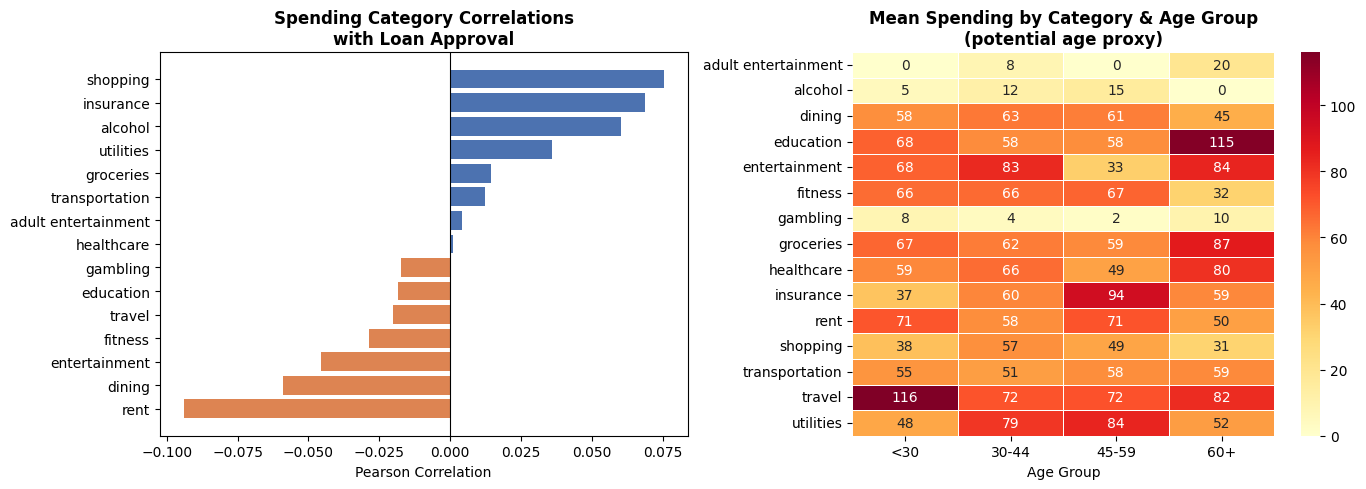

In [12]:
# Extract all spending categories and create per-category amount columns
all_categories = sorted(set(
    item['category']
    for items in df['spending_behavior_parsed']
    for item in items
))

for cat in all_categories:
    col = f'spend_{cat.lower()}'
    df[col] = df['spending_behavior_parsed'].apply(
        lambda items, c=cat: next((i['amount'] for i in items if i['category'] == c), 0)
    )

spend_cols = [f'spend_{cat.lower()}' for cat in all_categories]
print(f'Spending categories found: {all_categories}')

# Correlation of each spending category with loan_approved
loan_int   = df['decision.loan_approved'].astype(int)
spend_corr = df[spend_cols].corrwith(loan_int).sort_values()
spend_corr.index = [c.replace('spend_', '') for c in spend_corr.index]

print('\nCorrelation with loan_approved by spending category:')
print(spend_corr.to_string())

# Mean spending by age group — spending as age proxy
age_spend_means = df.groupby('age_group', observed=True)[spend_cols].mean()
age_spend_means.columns = [c.replace('spend_', '') for c in age_spend_means.columns]
print('\nMean spending amount by category and age group:')
print(age_spend_means.T.to_string())

# Heatmap — spending patterns by age group
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: correlation with approval outcome
colors = ['#DD8452' if v < 0 else '#4C72B0' for v in spend_corr.values]
axes[0].barh(spend_corr.index, spend_corr.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Spending Category Correlations\nwith Loan Approval', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pearson Correlation')

# Right: spending heatmap by age group
sns.heatmap(
    age_spend_means.T,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('Mean Spending by Category & Age Group\n(potential age proxy)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Rent spending has the strongest negative correlation with approval (−0.094), while shopping and insurance are slightly positive. Age-based spending differences exist but are modest, suggesting spending is a weaker age proxy than credit history in this dataset.

### 4. Interaction Effects

Bias can compound when protected attributes intersect. We examine the joint effect of **gender × age group** on approval rates — a concept known as *intersectional discrimination*. We also compute the DI ratio separately within each age subgroup to detect whether the gender gap widens or narrows across age brackets.

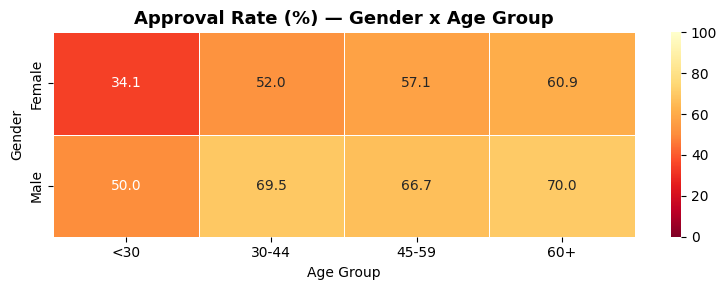

Disparate Impact ratio by age subgroup:
  <30: DI = 0.682  (Female 34.1% vs Male 50.0%) <- FAIL
  30-44: DI = 0.749  (Female 52.0% vs Male 69.5%) <- FAIL
  45-59: DI = 0.857  (Female 57.1% vs Male 66.7%)
  60+: DI = 0.870  (Female 60.9% vs Male 70.0%)


In [13]:
interaction = (
    df_gender
    .groupby(['applicant_info.gender', 'age_group'], observed=True)['decision.loan_approved']
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(interaction * 100, annot=True, fmt='.1f', cmap='YlOrRd_r', vmin=0, vmax=100, linewidths=0.5, ax=ax)
ax.set_title('Approval Rate (%) — Gender x Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Gender')
plt.tight_layout()
plt.show()

print('Disparate Impact ratio by age subgroup:')
for group in age_labels:
    subset = df_gender[df_gender['age_group'] == group]
    if len(subset) < 10:
        continue
    rates = subset.groupby('applicant_info.gender')['decision.loan_approved'].mean()
    if 'Male' in rates.index and 'Female' in rates.index and rates['Male'] > 0:
        di_sub = rates['Female'] / rates['Male']
        flag   = ' <- FAIL' if di_sub < 0.8 else ''
        print(f'  {group}: DI = {di_sub:.3f}  (Female {rates["Female"]:.1%} vs Male {rates["Male"]:.1%}){flag}')

The bias compounds at the intersection of gender and age, with women under 30 facing the harshest outcomes at only 34.1% approval (DI = 0.682), while the gender gap narrows for older applicants (DI = 0.870 for 60+). The disadvantage for young women cannot be explained by gender or age bias alone.

## 4 - Statistical Summary

All statistical tests conducted in this notebook are consolidated below for reference.

In [14]:
summary = pd.DataFrame([
    {
        'Test'                 : 'Chi-squared',
        'Variables'            : 'Gender vs Loan Approved',
        'Statistic'            : f'chi2 = {chi2_gender:.3f}',
        'p-value'              : f'{p_gender:.4f}',
        'Significant (p<0.05)' : 'Yes' if p_gender < 0.05 else 'No',
        'Notes'                : f'DI = {di:.3f} — {"FAIL" if di < 0.8 else "PASS"}'
    },
    {
        'Test'                 : 'Chi-squared',
        'Variables'            : 'Age Group vs Loan Approved',
        'Statistic'            : f'chi2 = {chi2_age:.3f}',
        'p-value'              : f'{p_age:.4f}',
        'Significant (p<0.05)' : 'Yes' if p_age < 0.05 else 'No',
        'Notes'                : 'Age-based discrimination check'
    },
    {
        'Test'                 : 'Independent t-test',
        'Variables'            : 'Income: Male vs Female',
        'Statistic'            : f't = {t_stat_income:.3f}',
        'p-value'              : f'{p_income:.4f}',
        'Significant (p<0.05)' : 'Yes' if p_income < 0.05 else 'No',
        'Notes'                : 'Income as gender proxy'
    },
    {
        'Test'                 : 'Pearson correlation',
        'Variables'            : 'Age vs Credit History Months',
        'Statistic'            : f'r = {r_credit_age:.3f}',
        'p-value'              : f'{p_credit_age:.4f}',
        'Significant (p<0.05)' : 'Yes' if p_credit_age < 0.05 else 'No',
        'Notes'                : 'Credit history as age proxy'
    },
    {
        'Test'                 : 'Chi-squared',
        'Variables'            : 'ZIP Prefix vs Loan Approved',
        'Statistic'            : f'chi2 = {chi2_zip:.3f}',
        'p-value'              : f'{p_zip:.4f}',
        'Significant (p<0.05)' : 'Yes' if p_zip < 0.05 else 'No',
        'Notes'                : 'ZIP code as geographic proxy'
    }
])

pd.set_option('display.max_colwidth', None)
print(summary.to_string(index=False))

               Test                    Variables     Statistic p-value Significant (p<0.05)                          Notes
        Chi-squared      Gender vs Loan Approved chi2 = 10.891  0.0010                  Yes              DI = 0.772 — FAIL
        Chi-squared   Age Group vs Loan Approved chi2 = 11.734  0.0084                  Yes Age-based discrimination check
 Independent t-test       Income: Male vs Female    t = -0.883  0.3775                   No         Income as gender proxy
Pearson correlation Age vs Credit History Months     r = 0.649  0.0000                  Yes    Credit history as age proxy
        Chi-squared  ZIP Prefix vs Loan Approved  chi2 = 7.417  0.0245                  Yes   ZIP code as geographic proxy


## 5 - Key Findings

The analysis reveals a consistent pattern of bias across multiple dimensions.

The most direct finding is the **gender disparate impact**, with women approved at 50.8% versus 65.9% for men, **producing a DI of 0.772, which falls below the legal threshold of 0.8**. This result is statistically significant (p = 0.001) and would not hold up under regulatory scrutiny.

Age compounds the issue, with applicants under 30 approved at only 41.5%, significantly lower than all older groups (p = 0.008). This is not coincidental, as the credit history analysis shows a strong structural link (r = 0.65) between age and credit history months, meaning **the algorithm effectively penalises youth through a variable that is mathematically impossible to improve quickly.**

Geographic location adds a further layer, with **NYC-area applicants approved at 64.3% versus 52.0% for LA-area applicants (p = 0.025)**, a difference that cannot be explained by financial profiles alone.

The one **hypothesis that did not hold was income as a gender proxy**, with male and female incomes being virtually identical in this dataset (p = 0.38).

Most critically, the **bias compounds at intersections: women under 30 face a DI of 0.682, far worse than either young applicants or women as standalone groups**. The dominant rejection reason across the dataset is `algorithm_risk_score`, which provides no explanation of which variables drove the decision. This means affected applicants cannot identify what to challenge, and NovaCred cannot demonstrate to regulators that its decisions are based on legitimate, non-discriminatory criteria — a direct conflict with the EU AI Act's transparency requirements and GDPR's right to explanation, what will be disscussed next.